In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [2]:
with open("../../data/bicycles/df_bicycles_stations.pk1", "rb") as f:
    stations_bikes = pickle.load(f)
    
with open("../../data/weather/df_stationsInfo.pkl", "rb") as f:
    stations_meteos = pickle.load(f)    

In [3]:
stations_bikes.head()

,name,capacity,lon,lat,short_name,station_id,rental_uris,region_id,address,station_idx
286,2112 W Peterson Ave,11,-87.683593,41.991178,CHI00611,a3af2216-a135-11e9-9cda-0a87ae2ba916,"{'android': 'https://chi.lft.to/lastmile_qr_scan', 'ios': 'https://chi.lft.to/lastmile_qr_scan'}",NaN,NaN,1701
105,21st St & Pulaski Rd,12,-87.725090,41.854370,CHI01823,1931696364106218226,"{'android': 'https://chi.lft.to/lastmile_qr_scan', 'ios': 'https://chi.lft.to/lastmile_qr_scan'}",NaN,NaN,938
88,63rd St Beach,15,-87.576324,41.780911,CHI00315,a3a547b8-a135-11e9-9cda-0a87ae2ba916,"{'android': 'https://chi.lft.to/lastmile_qr_scan', 'ios': 'https://chi.lft.to/lastmile_qr_scan'}",NaN,NaN,1379
876,900 W Harrison St,19,-87.649807,41.874754,CHI01748,a3a56ae5-a135-11e9-9cda-0a87ae2ba916,"{'android': 'https://chi.lft.to/lastmile_qr_scan', 'ios': 'https://chi.lft.to/lastmile_qr_scan'}",NaN,NaN,1385
243,Aberdeen St & 103rd St,16,-87.650220,41.707040,CHI01976,2014856134756363200,"{'android': 'https://chi.lft.to/lastmile_qr_scan', 'ios': 'https://chi.lft.to/lastmile_qr_scan'}",NaN,NaN,1095


In [4]:
stations_meteos.head()

,station,station_name,latitude,longitude
0,USW00004807,GARY,41.6167,-87.4167
1,USW00014819,CHICAGO MIDWAY AP,41.7842,-87.7553
2,USW00094846,CHICAGO OHARE INTL AP,41.9603,-87.9317


# Asignación de meteo más cercana a estacion de bicicletas

In [5]:
import pandas as pd
from scipy.spatial import cKDTree
import numpy as np

# Creamos los arrays de coordenadas
bikes_coords = stations_bikes[['lat', 'lon']].to_numpy()
meteo_coords = stations_meteos[['latitude', 'longitude']].to_numpy()

# Construimos un árbol KDTree con las estaciones meteorológicas
tree = cKDTree(meteo_coords)

# Buscamos la estación meteorológica más cercana para cada estación de bicicletas
distances, indices = tree.query(bikes_coords, k=1)  # k=1 → solo la más cercana

# Creamos columnas nuevas en stations_bikes_df
stations_bikes['nearest_meteo_station'] = stations_meteos.iloc[indices]['station'].values
stations_bikes['distance_deg'] = distances  # distancia en grados aproximadamente


# Mostrar ejemplo
print(stations_bikes[['station_id', 'nearest_meteo_station', 'distance_deg']].head())


                               station_id nearest_meteo_station  distance_deg
286  a3af2216-a135-11e9-9cda-0a87ae2ba916           USW00014819      0.219047
105                   1931696364106218226           USW00014819      0.076397
88   a3a547b8-a135-11e9-9cda-0a87ae2ba916           USW00014819      0.179006
876  a3a56ae5-a135-11e9-9cda-0a87ae2ba916           USW00014819      0.139028
243                   2014856134756363200           USW00014819      0.130367


In [6]:
stations_bikes['nearest_meteo_station'].unique()

array(['USW00014819', 'USW00004807', 'USW00094846'], dtype=object)

In [7]:
stations_bikes.to_pickle("../../data/join/df_bikesStations.pkl")

# Se realiza la correlacion de estacion de inicio y estacion meteorologica en los datos de viajes

In [8]:
with open("../../data/bicycles/df_bicycles_preprocesed.pk1", "rb") as f:
    df_bicycles = pickle.load(f)
    
with open("../../data/weather/dict_weather_interpolated_per_year.pk1", "rb") as f:
    dict_weather = pickle.load(f)    

In [9]:
# Asignar la estación meteo más cercana según start_station_id
df_bicycles = df_bicycles.merge(
    stations_bikes[['station_id', 'nearest_meteo_station']],
    left_on='start_station_id',
    right_on='station_id',
    how='left'
)

df_bicycles = df_bicycles.drop(columns=['station_id'])

# Se realiza la correlacion enre datos meteorlogicos y fecha

In [10]:
from collections import defaultdict

# Diccionario final vacío
flattened = defaultdict(list)

# Recorremos cada año y cada estación
for year, stations in dict_weather.items():
    for station, df in stations.items():
        flattened[station].append(df)

In [11]:
# Concatenamos todos los DataFrames de cada estación
flattened = {station: pd.concat(dfs, ignore_index=True) for station, dfs in flattened.items()}


In [12]:
# Agrupamos por estación
dict_bicycles_by_station = {station: group.copy() for station, group in df_bicycles.groupby('nearest_meteo_station')}

for key, df in dict_bicycles_by_station.items():
    dict_bicycles_by_station[key] = df.drop(columns=['nearest_meteo_station'])

In [13]:
keys = dict_bicycles_by_station.keys()
keys

dict_keys(['USW00004807', 'USW00014819', 'USW00094846'])

In [14]:
df_merged_all = []

for station_id in dict_bicycles_by_station.keys():
    # Ordenar DataFrames
    bikes_df = dict_bicycles_by_station[station_id].sort_values('started_at')
    weather_df = flattened[station_id].sort_values('DATE')
    
    # Merge asof
    df_merged = pd.merge_asof(
        bikes_df,
        weather_df,
        left_on='started_at',
        right_on='DATE',
        direction='nearest',
        tolerance=pd.Timedelta('1h')
    )
    
    # Columnas numéricas del weather
    weather_cols_numeric = weather_df.select_dtypes(include=['float64', 'int']).columns
    
    # Usamos 'started_at' como índice temporal para interpolación (sin NaNs)
    df_merged.set_index('started_at', inplace=True)
    
    # Interpolación lineal
    df_merged[weather_cols_numeric] = df_merged[weather_cols_numeric].interpolate(
        method='time', limit_direction='both'
    )
    
    # Restauramos índice normal
    df_merged.reset_index(inplace=True)
    
    # Guardamos merge de esta estación
    df_merged_all.append(df_merged)

# Concatenamos todas las estaciones
df_merged_final = pd.concat(df_merged_all, ignore_index=True)


In [15]:
df_merged_final.describe()

,started_at,ended_at,year,month,day,time_hms_ms,DATE,temperature,wind_speed,precipitation,relative_humidity,snow_depth,station_level_pressure
count,9510782,9510782,9.510782e+06,9.510782e+06,9.510782e+06,9510782,9486004,9.510782e+06,9.510782e+06,9.510782e+06,9.510782e+06,9.510782e+06,9.510782e+06
mean,2023-03-14 11:24:51.477330176,2023-03-14 11:40:48.369607424,2.022693e+03,6.591589e+00,1.572324e+01,0 days 14:34:59.345832130,2023-03-15 02:26:51.406760192,1.724990e+01,4.349339e+00,5.633695e-02,5.889126e+01,1.770667e-01,9.932694e+02
min,2022-01-01 00:00:05,2022-01-01 00:01:48,2.022000e+03,1.000000e+00,1.000000e+00,0 days 00:00:00,2022-01-01 00:06:00,-2.330000e+01,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,9.578100e+02
25%,2022-08-05 20:55:58.500000,2022-08-05 21:14:34,2.022000e+03,5.000000e+00,8.000000e+00,0 days 11:08:04,2022-08-06 11:15:00,1.022000e+01,2.850000e+00,0.000000e+00,4.538333e+01,0.000000e+00,9.892733e+02
50%,2023-04-13 18:15:57,2023-04-13 18:33:31,2.023000e+03,7.000000e+00,1.600000e+01,0 days 15:26:53,2023-04-14 15:28:00,1.929333e+01,4.183333e+00,0.000000e+00,5.900000e+01,0.000000e+00,9.931833e+02
75%,2023-09-09 18:03:29,2023-09-09 18:22:52.249999872,2.023000e+03,9.000000e+00,2.300000e+01,0 days 18:09:12,2023-09-10 06:42:00,2.483500e+01,5.700000e+00,0.000000e+00,7.254717e+01,0.000000e+00,9.970500e+02
max,2024-05-31 23:59:47,2024-06-01 17:56:00,2.024000e+03,1.200000e+01,3.100000e+01,0 days 23:59:59,2024-06-01 00:00:00,3.830000e+01,1.650000e+01,3.930000e+01,1.000000e+02,2.300000e+02,1.017700e+03
std,NaN,NaN,6.848749e-01,2.764110e+00,8.774035e+00,0 days 04:54:31.207139121,NaN,9.674967e+00,2.178972e+00,5.650406e-01,1.742219e+01,3.153545e+00,6.306474e+00


In [16]:
df_merged_final.head()

,started_at,ride_id,rideable_type,ended_at,member_casual,year,month,day,time_hms_ms,day_type,event,start_station_id,end_station_id,DATE,temperature,wind_speed,precipitation,relative_humidity,snow_depth,station_level_pressure
0,2022-01-04 04:38:28,12E6E4CC93D5FDBB,classic_bike,2022-01-04 04:51:48,casual,2022,1,4,0 days 04:38:28,Normal,False,8fd03909-317e-4b6c-b8e9-f4c28b4c90b1,bbb67562-1f82-4dfa-a532-231ddc35444e,2022-01-04 04:38:00,-5.47,3.100000,0.0,74.85,0.0,1004.100000
1,2022-01-04 11:26:49,03A4B2FF57D83F87,classic_bike,2022-01-04 11:35:30,casual,2022,1,4,0 days 11:26:49,Normal,False,a3b2905a-a135-11e9-9cda-0a87ae2ba916,a3ad09b2-a135-11e9-9cda-0a87ae2ba916,2022-01-04 11:27:00,-5.00,4.600000,0.0,80.00,0.0,1001.100000
2,2022-01-04 13:13:55,656B583500F94041,classic_bike,2022-01-04 13:52:27,member,2022,1,4,0 days 13:13:55,Normal,False,2a80f8d9-85dc-4c36-ba07-86d775ffd1ee,2a80f8d9-85dc-4c36-ba07-86d775ffd1ee,2022-01-04 13:14:00,-5.00,4.841667,0.0,82.90,0.0,1000.278333
3,2022-01-12 15:29:54,E1E90907D0DAAD57,electric_bike,2022-01-12 15:36:05,casual,2022,1,12,0 days 15:29:54,Normal,False,bbb67562-1f82-4dfa-a532-231ddc35444e,ff21c158-de98-46c6-9ef7-7082bdb7c634,2022-01-12 15:30:00,0.75,2.850000,0.0,76.25,0.0,995.800000
4,2022-01-16 08:28:04,8CDE4F5C9F79729C,classic_bike,2022-01-16 08:58:12,casual,2022,1,16,0 days 08:28:04,Weekend,False,b09832de-1c8e-4b92-bd72-bd98dc80b92c,a3ad0ecb-a135-11e9-9cda-0a87ae2ba916,2022-01-16 08:28:00,-9.83,1.885000,0.0,74.30,0.0,1000.840000


# Se borran columnas innecesarias resultado del merge

In [17]:
df_merged_final = df_merged_final.drop(columns=['DATE'])

In [18]:
df_merged_final.head()

,started_at,ride_id,rideable_type,ended_at,member_casual,year,month,day,time_hms_ms,day_type,event,start_station_id,end_station_id,temperature,wind_speed,precipitation,relative_humidity,snow_depth,station_level_pressure
0,2022-01-04 04:38:28,12E6E4CC93D5FDBB,classic_bike,2022-01-04 04:51:48,casual,2022,1,4,0 days 04:38:28,Normal,False,8fd03909-317e-4b6c-b8e9-f4c28b4c90b1,bbb67562-1f82-4dfa-a532-231ddc35444e,-5.47,3.100000,0.0,74.85,0.0,1004.100000
1,2022-01-04 11:26:49,03A4B2FF57D83F87,classic_bike,2022-01-04 11:35:30,casual,2022,1,4,0 days 11:26:49,Normal,False,a3b2905a-a135-11e9-9cda-0a87ae2ba916,a3ad09b2-a135-11e9-9cda-0a87ae2ba916,-5.00,4.600000,0.0,80.00,0.0,1001.100000
2,2022-01-04 13:13:55,656B583500F94041,classic_bike,2022-01-04 13:52:27,member,2022,1,4,0 days 13:13:55,Normal,False,2a80f8d9-85dc-4c36-ba07-86d775ffd1ee,2a80f8d9-85dc-4c36-ba07-86d775ffd1ee,-5.00,4.841667,0.0,82.90,0.0,1000.278333
3,2022-01-12 15:29:54,E1E90907D0DAAD57,electric_bike,2022-01-12 15:36:05,casual,2022,1,12,0 days 15:29:54,Normal,False,bbb67562-1f82-4dfa-a532-231ddc35444e,ff21c158-de98-46c6-9ef7-7082bdb7c634,0.75,2.850000,0.0,76.25,0.0,995.800000
4,2022-01-16 08:28:04,8CDE4F5C9F79729C,classic_bike,2022-01-16 08:58:12,casual,2022,1,16,0 days 08:28:04,Weekend,False,b09832de-1c8e-4b92-bd72-bd98dc80b92c,a3ad0ecb-a135-11e9-9cda-0a87ae2ba916,-9.83,1.885000,0.0,74.30,0.0,1000.840000


# Se observan los valores nulos

In [82]:
df_merged_final.isna().sum()

started_at                0
ride_id                   0
rideable_type             0
ended_at                  0
member_casual             0
year                      0
month                     0
day                       0
time_hms_ms               0
day_type                  0
event                     0
start_station_id          0
end_station_id            0
temperature               0
wind_speed                0
precipitation             0
relative_humidity         0
snow_depth                0
station_level_pressure    0
dtype: int64

# Se observa la cantidad de datos

In [83]:
df_merged_final["ride_id"].count()

np.int64(9510782)

In [84]:
df_merged_final.dtypes

started_at                 datetime64[ns]
ride_id                            object
rideable_type                      object
ended_at                   datetime64[ns]
member_casual                      object
year                                int64
month                               int64
day                                 int64
time_hms_ms               timedelta64[ns]
day_type                           object
event                                bool
start_station_id                   object
end_station_id                     object
temperature                       float64
wind_speed                        float64
precipitation                     float64
relative_humidity                 float64
snow_depth                        float64
station_level_pressure            float64
dtype: object

# Se guardan los datos

In [85]:
df_merged_final.to_pickle("../../data/join/df_data.pk1")

# Se muestran graficas de los datos

In [86]:
with open("../../data/join/df_data.pk1", "rb") as f:
    df = pickle.load(f)

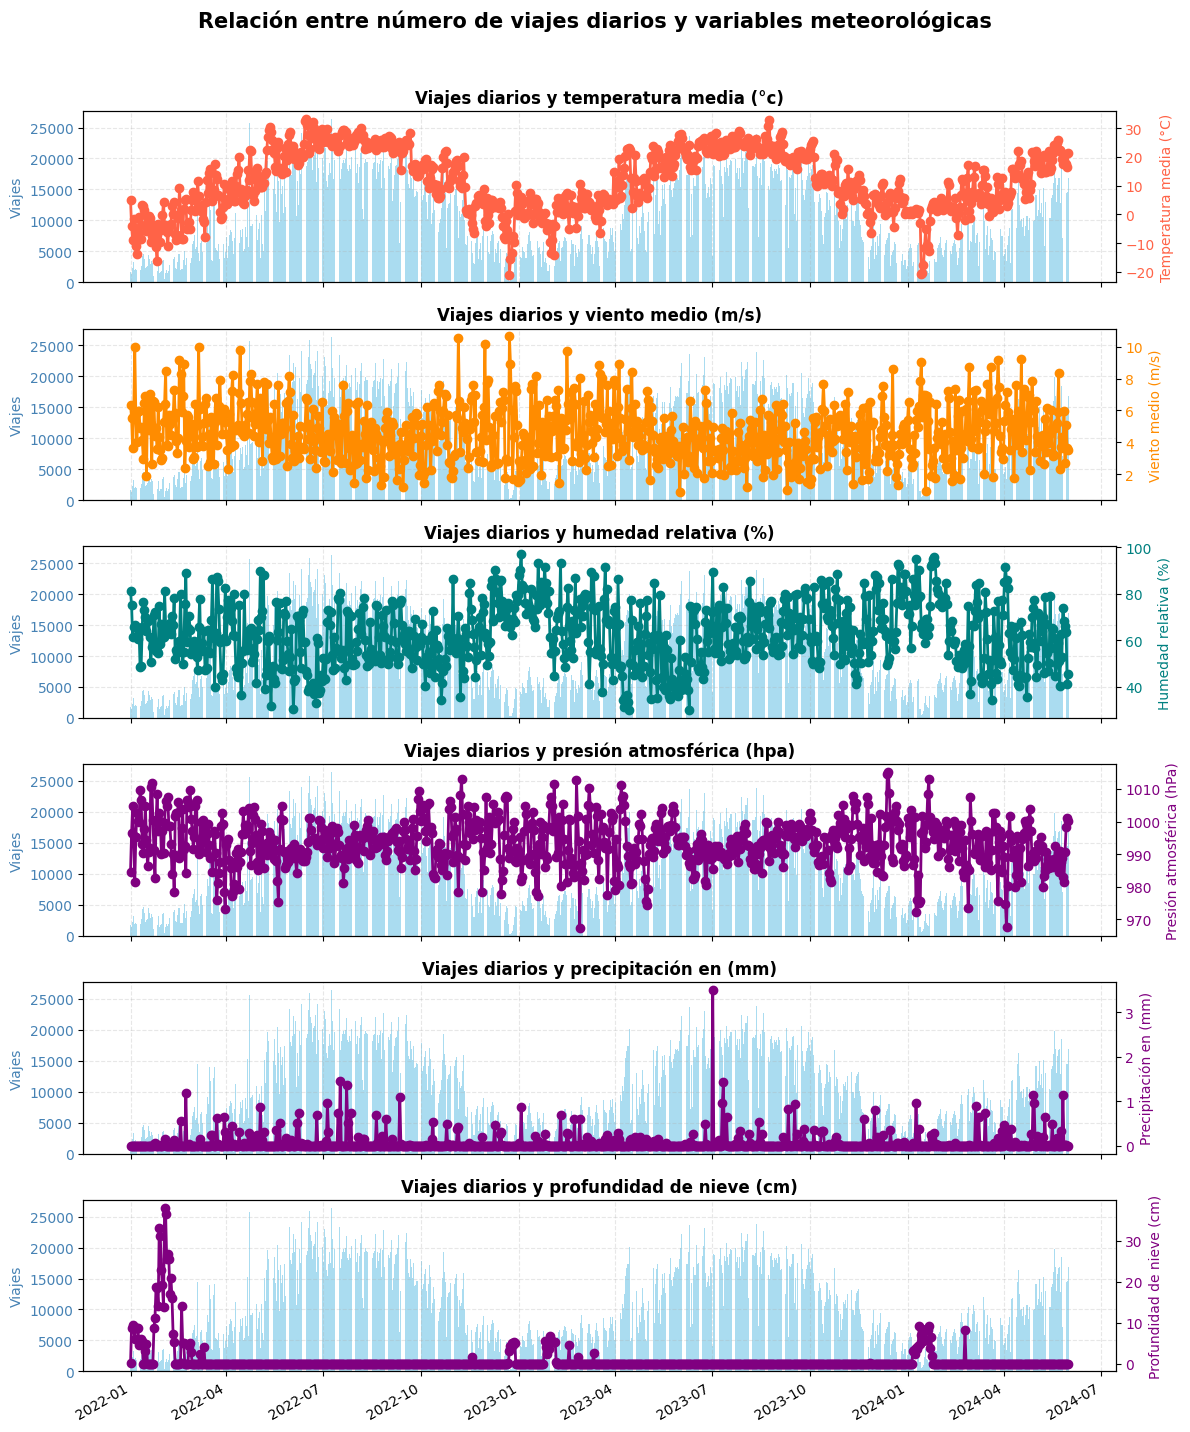

In [92]:
# Agrupar por dia y calcular medias
df_daily = (
    df.groupby(df['started_at'].dt.date)
    .agg(
        trips=('started_at', 'count'),
        mean_temp=('temperature', 'mean'),
        mean_wind=('wind_speed', 'mean'),
        mean_humidity=('relative_humidity', 'mean'),
        mean_pressure=('station_level_pressure', 'mean'),
        mean_precipitation=('precipitation', 'mean'),
        mean_snow_depth=('snow_depth', 'mean')
    )
    .reset_index()
)

# Configurar figura con 6 subgráficos
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

# Lista de variables y etiquetas
metrics = [
    ('mean_temp', 'Temperatura media (°C)', 'tomato'),
    ('mean_wind', 'Viento medio (m/s)', 'darkorange'),
    ('mean_humidity', 'Humedad relativa (%)', 'teal'),
    ('mean_pressure', 'Presión atmosférica (hPa)', 'purple'),
    ('mean_precipitation', 'Precipitación en (mm)', 'purple'),
    ('mean_snow_depth', 'Profundidad de nieve (cm)', 'purple')
]

# Dibujar cada grafico
for ax, (col, ylabel, color) in zip(axes, metrics):
    # Eje izquierdo: número de viajes
    ax.bar(df_daily['started_at'], df_daily['trips'], color='skyblue', alpha=0.7, label='Viajes por día')
    ax.set_ylabel('Viajes', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    
    # Eje derecho: variable meteorologica
    ax2 = ax.twinx()
    ax2.plot(df_daily['started_at'], df_daily[col], color=color, marker='o', linewidth=2, label=ylabel)
    ax2.set_ylabel(ylabel, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Titulo de cada subgrafico
    ax.set_title(f'Viajes diarios y {ylabel.lower()}', fontsize=12, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

# Formato general
plt.suptitle('Relación entre número de viajes diarios y variables meteorológicas', fontsize=15, weight='bold', y=1.02)
plt.xlabel('Fecha')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# Grado de correlación

In [93]:
correlations = df_daily[['trips', 'mean_temp', 'mean_wind', 'mean_humidity', 'mean_pressure', 'mean_precipitation', 'mean_snow_depth']].corr()

print(correlations['trips'])

trips                 1.000000
mean_temp             0.891486
mean_wind            -0.255599
mean_humidity        -0.433164
mean_pressure        -0.062150
mean_precipitation   -0.101965
mean_snow_depth      -0.319432
Name: trips, dtype: float64


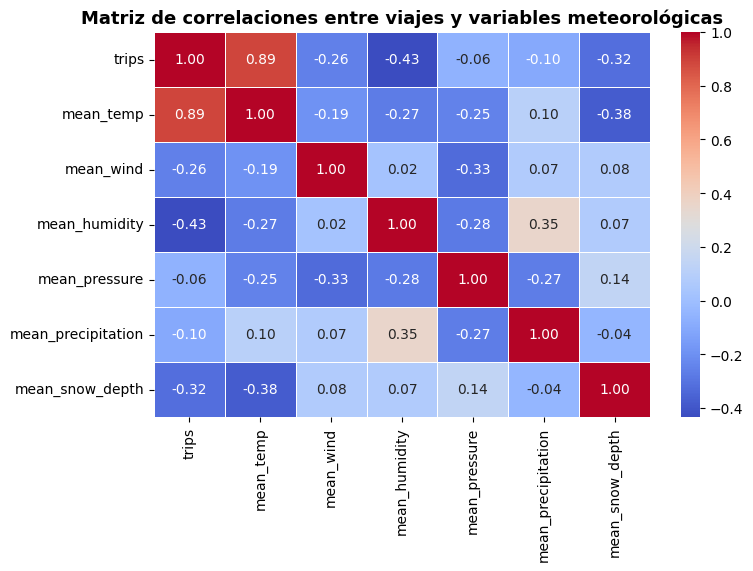

In [94]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlaciones entre viajes y variables meteorológicas', fontsize=13, weight='bold')
plt.show()

C:\Users\burvu\AppData\Local\Temp\ipykernel_13404\2746021259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\burvu\AppData\Local\Temp\ipykernel_13404\2746021259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\burvu\AppData\Local\Temp\ipykernel_13404\2746021259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\burvu\AppData\Local\Temp\ipykernel_13404\2746021259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

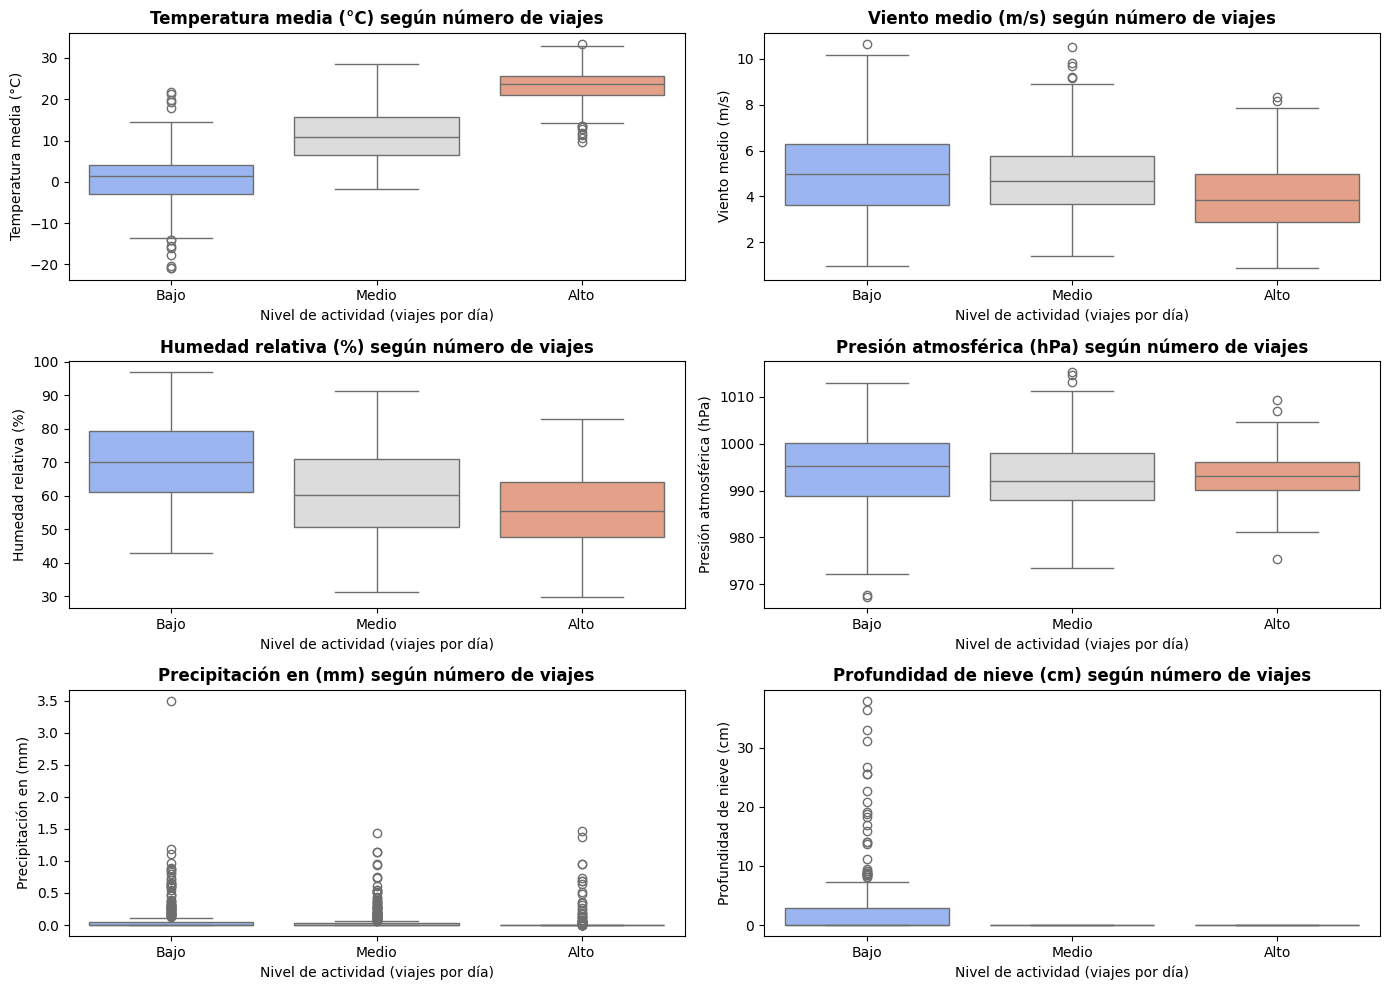

In [96]:
# Crear categorias de viajes (bajo/medio/alto 33% de los datos para cada grupo)
df_daily['viajes_cat'] = pd.qcut(df_daily['trips'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# Lista de variables meteorológicas y sus etiquetas
variables = {
    'mean_temp': 'Temperatura media (°C)',
    'mean_wind': 'Viento medio (m/s)',
    'mean_humidity': 'Humedad relativa (%)',
    'mean_pressure': 'Presión atmosférica (hPa)',
    'mean_precipitation': 'Precipitación en (mm)',
    'mean_snow_depth': 'Profundidad de nieve (cm)'
}

# Configurar figura con subplots
fig, axes = plt.subplots(3, 2, figsize=(14,10))
axes = axes.flatten()

# Dibujar boxplot para cada variable
for ax, (var, label) in zip(axes, variables.items()):
    sns.boxplot(
        x='viajes_cat',
        y=var,
        data=df_daily,
        palette='coolwarm',
        ax=ax
    )
    ax.set_title(f'{label} según número de viajes', fontsize=12, weight='bold')
    ax.set_xlabel('Nivel de actividad (viajes por día)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

# Analisis de dias festivos y días con evento

C:\Users\burvu\AppData\Local\Temp\ipykernel_13404\3349383452.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


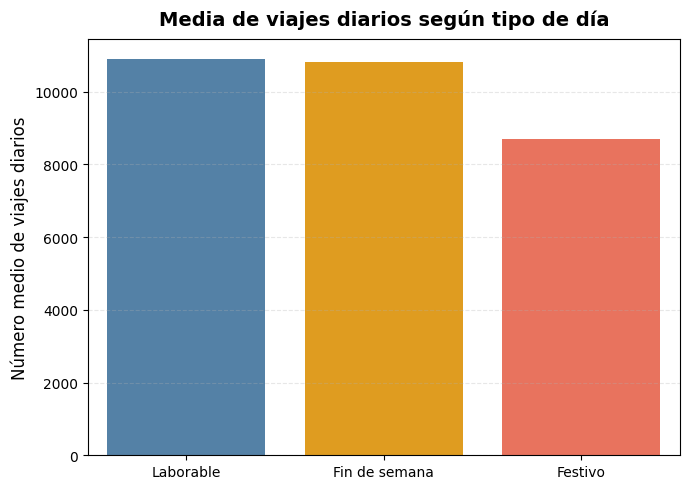

In [97]:
# Agrupar por dia para contar los viajes y conservar el tipo de dia
df_daily = (
    df.groupby([df['started_at'].dt.date, 'day_type'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

# Calcular la media de viajes para cada tipo de dia
df_summary = (
    df_daily.groupby('day_type', as_index=False)
    .agg(mean_trips=('trips', 'mean'))
)

# Orden de categorias
order = ['Normal', 'Weekend', 'Holiday']

labels = {
    'Normal': 'Laborable',
    'Weekend': 'Fin de semana',
    'Holiday': 'Festivo'
}
df_summary['Tipo de día'] = df_summary['day_type'].map(labels)

plt.figure(figsize=(7,5))
sns.barplot(
    data=df_summary,
    x='Tipo de día',
    y='mean_trips',
    order=[labels[o] for o in order],
    palette=['steelblue', 'orange', 'tomato']
)

plt.title('Media de viajes diarios según tipo de día', fontsize=14, weight='bold', pad=10)
plt.xlabel('')
plt.ylabel('Número medio de viajes diarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\burvu\AppData\Local\Temp\ipykernel_13404\3572794228.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


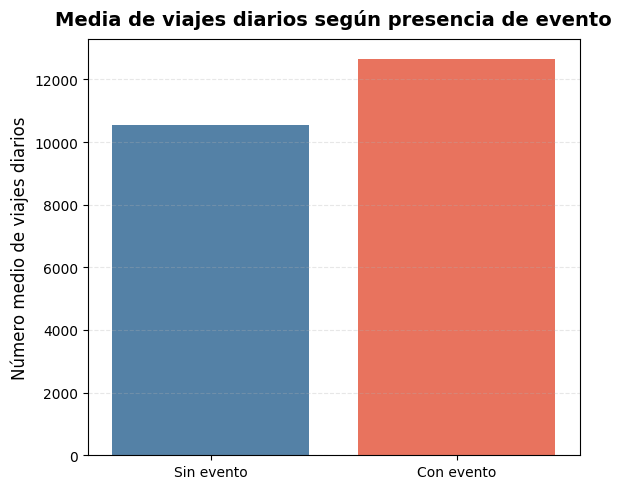

In [98]:
# Agrupar por dia y por evento
df_daily = (
    df.groupby([df['started_at'].dt.date, 'event'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

# Calcular la media de viajes para cada tipo de evento
df_summary = (
    df_daily.groupby('event', as_index=False)
    .agg(mean_trips=('trips', 'mean'))
)

# Mapear etiquetas legibles
labels = {False: 'Sin evento', True: 'Con evento'}
df_summary['Evento'] = df_summary['event'].map(labels)

plt.figure(figsize=(6,5))
sns.barplot(
    data=df_summary,
    x='Evento',
    y='mean_trips',
    palette=['steelblue', 'tomato']
)

plt.title('Media de viajes diarios según presencia de evento', fontsize=14, weight='bold', pad=10)
plt.xlabel('')
plt.ylabel('Número medio de viajes diarios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [99]:
df_daily = (
    df.groupby([df['started_at'].dt.date, 'day_type'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

df_daily["normal"] = df_daily["day_type"] == "Normal"
df_daily["weekend"] = df_daily["day_type"] == "Weekend"
df_daily["holiday"] = df_daily["day_type"] == "Holiday"

# Calcular correlación de Pearson con trips
corr_normal = df_daily['trips'].corr(df_daily['normal'])
corr_weekend = df_daily['trips'].corr(df_daily['weekend'])
corr_holiday = df_daily['trips'].corr(df_daily['holiday'])

print(f"Correlación entre tipo de día 'Normal' y número de viajes: {corr_normal:.3f}")
print(f"Correlación entre tipo de día 'Weekend' y número de viajes: {corr_weekend:.3f}")
print(f"Correlación entre tipo de día 'Holiday' y número de viajes: {corr_holiday:.3f}")

Correlación entre tipo de día 'Normal' y número de viajes: 0.029
Correlación entre tipo de día 'Weekend' y número de viajes: 0.003
Correlación entre tipo de día 'Holiday' y número de viajes: -0.072


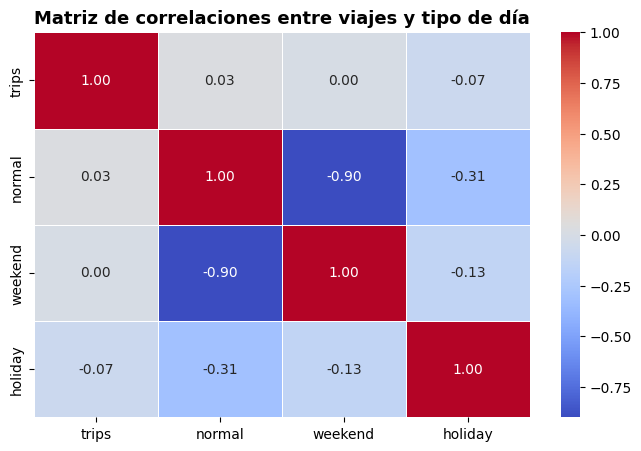

In [100]:
df_daily = (
    df.groupby([df['started_at'].dt.date, 'day_type'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

df_daily["normal"] = df_daily["day_type"] == "Normal"
df_daily["weekend"] = df_daily["day_type"] == "Weekend"
df_daily["holiday"] = df_daily["day_type"] == "Holiday"

cor = df_daily[['trips', 'normal', 'weekend', 'holiday']].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlaciones entre viajes y tipo de día', fontsize=13, weight='bold')
plt.show()


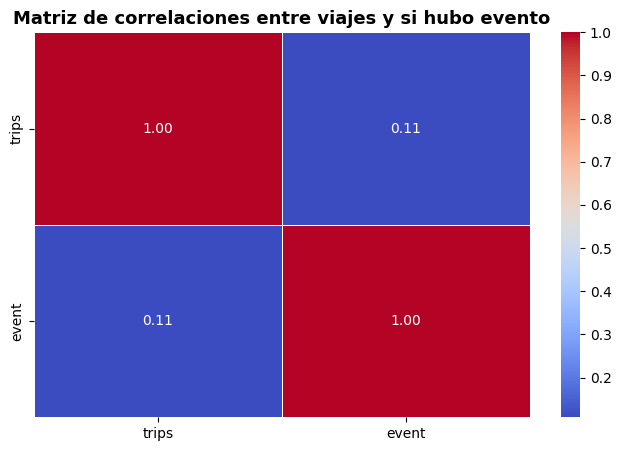

In [101]:
df_daily = (
    df.groupby([df['started_at'].dt.date, 'event'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

cor = df_daily[['trips', 'event']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlaciones entre viajes y si hubo evento', fontsize=13, weight='bold')
plt.show()

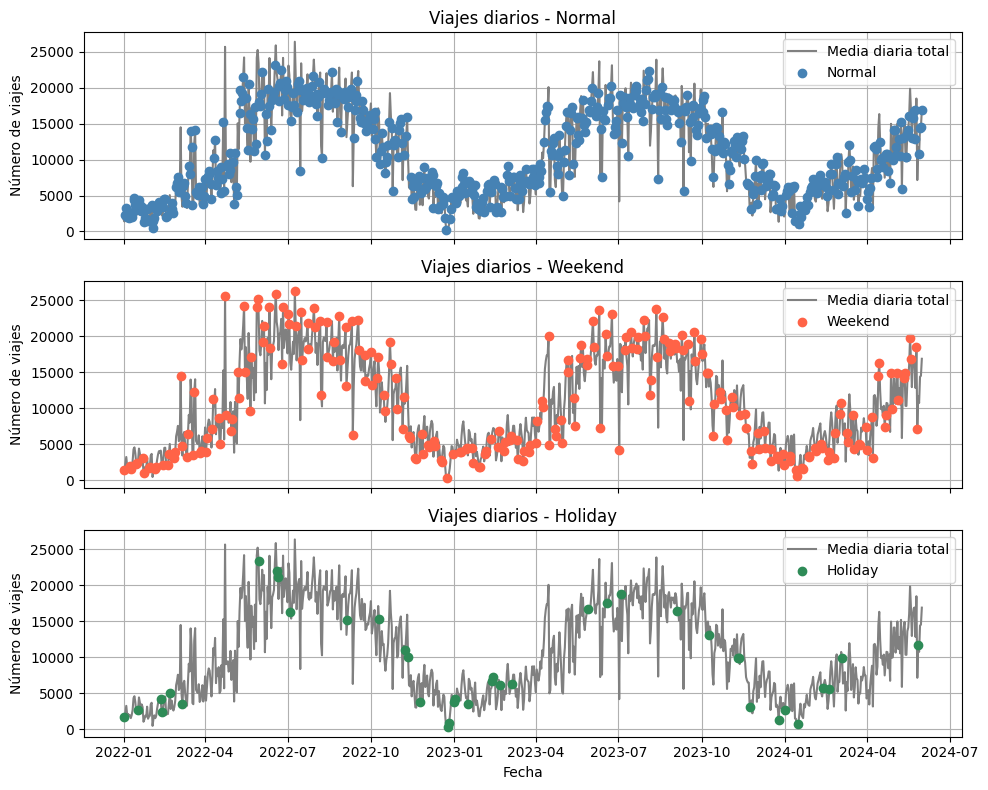

In [102]:
df_daily = (
    df.groupby([df['started_at'].dt.date, 'day_type'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

# Calcular la media total diaria
df_mean = (
    df_daily.groupby("started_at", as_index=False)
    .agg(trips=("trips", "mean"))
)

# Unir con la información del tipo de día
df_plot = df_mean.merge(
    df_daily[["started_at", "day_type"]],
    on="started_at",
    how="left"
).drop_duplicates(subset=["started_at"])

# Crear figura con tres subgraficos (uno por tipo de día)
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

day_types = ["Normal", "Weekend", "Holiday"]
colors = ["steelblue", "tomato", "seagreen"]

for ax, d_type, color in zip(axes, day_types, colors):
    # Línea de la media total diaria
    ax.plot(df_plot["started_at"], df_plot["trips"], color="gray", label="Media diaria total")
    
    # Puntos del tipo de día actual
    subset = df_plot[df_plot["day_type"] == d_type]
    ax.scatter(subset["started_at"], subset["trips"], color=color, label=d_type, zorder=5)
    
    ax.set_title(f"Viajes diarios - {d_type}")
    ax.set_ylabel("Número de viajes")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()


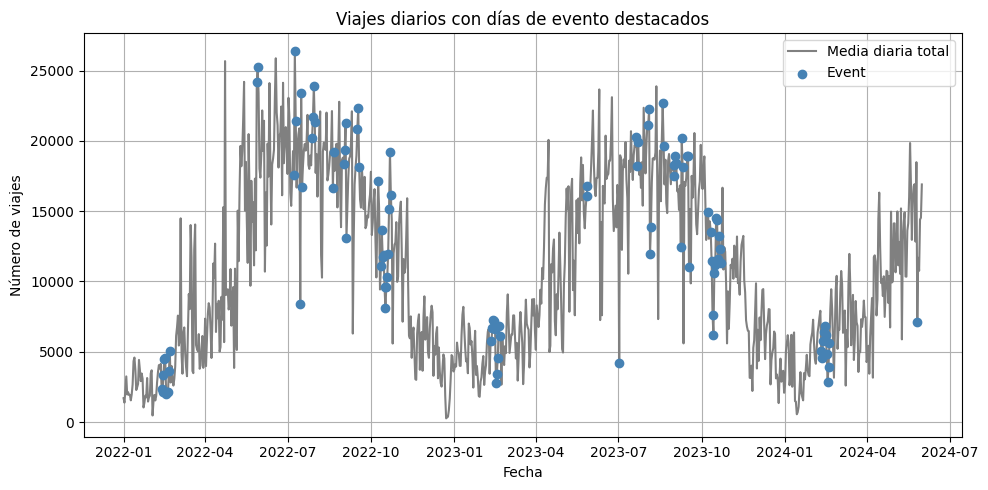

In [103]:
df_daily = (
    df.groupby([df['started_at'].dt.date, 'event'])
    .agg(trips=('started_at', 'count'))
    .reset_index()
)

# Calcular la media total diaria
df_mean = (
    df_daily.groupby("started_at", as_index=False)
    .agg(trips=("trips", "mean"))
)

# Unir con la información del evento (True/False)
df_plot = df_mean.merge(
    df_daily[["started_at", "event"]],
    on="started_at",
    how="left"
).drop_duplicates(subset=["started_at"])

# Filtrar solo los días con evento (True)
df_event = df_plot[df_plot["event"] == True]

# Crear la figura
plt.figure(figsize=(10, 5))

# Línea de la media total diaria
plt.plot(df_plot["started_at"], df_plot["trips"], color="gray", label="Media diaria total")

# Puntos para los días con evento
plt.scatter(df_event["started_at"], df_event["trips"], color="steelblue", label="Event", zorder=5)

# Ajustes de estilo
plt.title("Viajes diarios con días de evento destacados")
plt.xlabel("Fecha")
plt.ylabel("Número de viajes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


